In [1]:



import itertools
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np
import json
import math
import pprint
import pandas as pd
from time import thread_time_ns
from datetime import datetime
import statistics
from tqdm import tqdm
from skimage.feature import canny
from skimage.transform import hough_ellipse
from skimage.draw import ellipse_perimeter


In [2]:
img_path = "/Users/jdreiling/Desktop/puck/puck/images/custom/jack_cole/medium/B/custom_jack_cole_medium_B_4.jpg"
image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)


loaded image
blurred
grayed
edges


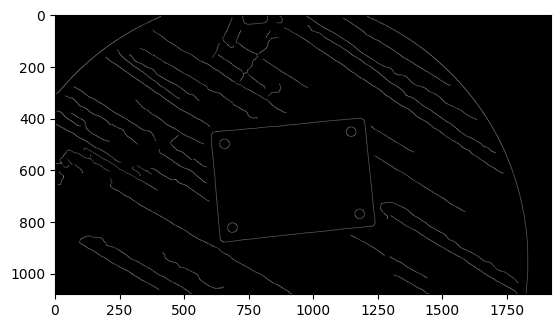

In [3]:
print("loaded image")
imageBlurred = cv.medianBlur(image, 3)
print("blurred")
gray = cv.cvtColor(imageBlurred, cv.COLOR_RGBA2GRAY)
print('grayed')
edges = canny(gray, sigma=10, low_threshold=1, high_threshold=2)
print("edges")

# Draw the edge (white) and the resulting ellipse (red)
plt.imshow(edges, cmap = "gray")
plt.show()

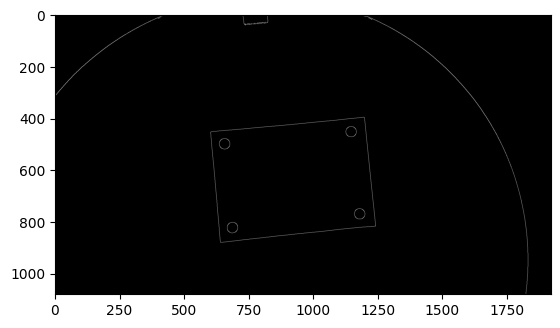

In [4]:
threshold = 100
edges_cv = cv.Canny(gray, threshold, threshold * 2)
plt.imshow(edges_cv, cmap = "gray")
plt.show()

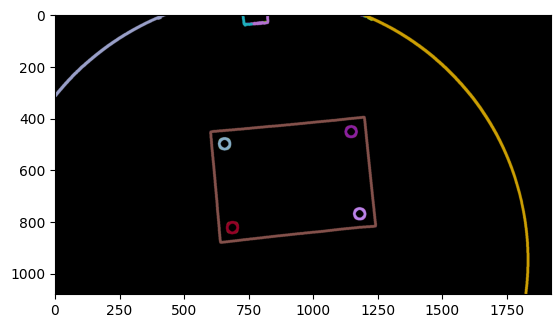

In [24]:
import random as rng
contours, _ = cv.findContours(edges_cv, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
minRect = [None]*len(contours)
minEllipse = [None]*len(contours)
drawing = np.zeros((edges_cv.shape[0], edges_cv.shape[1], 3), dtype=np.uint8)
    
for i, c in enumerate(contours):
    color = (rng.randint(0,256), rng.randint(0,256), rng.randint(0,256))
    # contour
    cv.drawContours(drawing, contours, i, color, 10)

plt.imshow(drawing)



In [23]:
for i, c in enumerate(contours):
    minRect[i] = cv.minAreaRect(c)
    if c.shape[0] > 5:
        minEllipse[i] = cv.fitEllipse(c)

print(len(minEllipse))

20


In [18]:
print(minRect)

[((916.5582275390625, 636.435546875), (604.1892700195312, 429.8421325683594), -5.9315266609191895), ((916.5582275390625, 636.435546875), (604.1892700195312, 429.8421325683594), -5.9315266609191895), ((685.5, 823.5), (41.0, 41.0), -90.0), ((685.2501220703125, 823.2501220703125), (41.01219177246094, 40.305084228515625), -45.0), ((1176.5, 770.0), (40.0, 41.0), -90.0), ((1176.2501220703125, 770.2500610351562), (39.59798049926758, 40.305084228515625), -45.0), ((654.5, 500.5), (41.0, 41.0), -90.0), ((654.5000610351562, 500.00006103515625), (40.305084228515625, 40.305084228515625), -45.0), ((1143.5, 453.0), (40.0, 41.0), -90.0), ((1143.5001220703125, 453.50006103515625), (39.59798049926758, 39.59798049926758), -45.0), ((747.5, 37.0), (0.0, 11.0), -90.0), ((766.0, 36.0), (0.0, 0.0), -90.0), ((809.5399780273438, 31.779996871948242), (9.050968170166016, 0.8485281467437744), -8.130102157592773), ((1217.192626953125, 17.14221954345703), (1.2868425846099854, 15.645294189453125), -61.69924545288086)

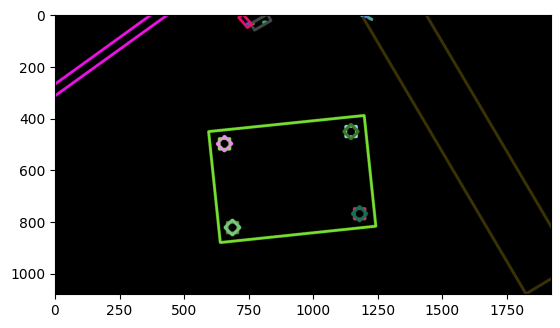

In [ ]:
drawing = np.zeros((edges_cv.shape[0], edges_cv.shape[1], 3), dtype=np.uint8)


for i, c in enumerate(contours):
    color = (rng.randint(0,256), rng.randint(0,256), rng.randint(0,256))
    # contour
    cv.drawContours(drawing, contours, i, color, 10)
    box = cv.boxPoints(minRect[i])
    box = np.intp(box) #np.intp: Integer used for indexing (same as C ssize_t; normally either int32 or int64)
    cv.drawContours(drawing, [box], 0, color, 10)

plt.imshow(drawing)

        

In [27]:

result = hough_ellipse(edges,min_size=10, max_size=50)
print("ellipsified")
circles = result.sort(order='accumulator')       
print(circles)

KeyboardInterrupt: 